# Medical Insurance Cost

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from tqdm import tqdm
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Paso 1: Recopilación de datos y definición del problema

In [148]:
df = pd.read_csv('../data/raw/medical_insurance_cost.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


- `age`: Edad del beneficiario principal (numérico)
- `sex`: Género del beneficiario principal (categórico)
- `bmi`: índice de masa corporal (numérico)
- `children`: Número de niños/dependientes cubiertos por un seguro médico (numérico)
- `smoker`: ¿Es fumador? (categórico)
- `region`: Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
- `charges`: Prima del seguro médico (numérico)

> ¿Podemos predecir la prima del seguro de un cliente a partir de sus características fisiológicas (edad, peso, altura, presión arterial, historial médico, etc.) usando un modelo predictivo?

In [149]:
df.shape

(1338, 7)

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [151]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


> ### Observaciones:
>
> - Existen un total de 1338 filas y 7 columnas, entre las cuales se encuentra el target o clase a predecir, `charges`.
> - Ninguna de las variables contiene valores nulos.
> - Los datos incluyen 4 características numéricas y 3 características categóricas.

## Paso 2: EDA

### Limpieza de datos: Eliminar duplicados

In [152]:
df_original = df.copy()
df_original

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [153]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [154]:
df.duplicated().sum()

np.int64(1)

> #### Observaciones: 
>
> Hay solo una fila duplicada. 

In [155]:
# To show all the duplicated raws 
duplicated = df[df.duplicated(keep=False)]
duplicated

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [156]:
# To modify deleting duplicated ones and create a new copy of data frame
df.drop_duplicates(inplace=True)

In [157]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Limpieza de datos: Eliminar información irrelevante

- ¿Son todas las características imprescindibles para realizar una predicción?
Podemos decir directamente que la columna `region` no afecta a nuestro target `charges` , porque el precio no puede variar según la ubicación. Los factores mucho más importantes son los que quedan, como `sex` o `smoker`. 

In [158]:
df.drop(['region'], axis=1, inplace=True)
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


### Análisis de Variables

Las variables categóricas son: `Sex`, `Smoker` y `Region`:

In [159]:
df['sex_n'] = pd.factorize(df['sex'])[0]
df['smoker_n'] = pd.factorize(df['smoker'])[0]

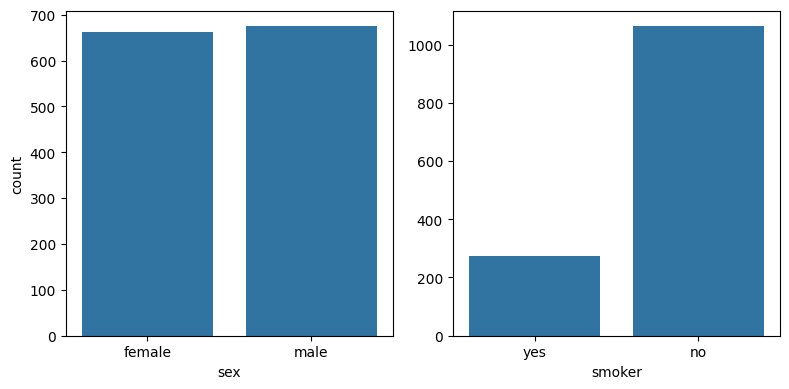

In [160]:
fig, axis = plt.subplots(1, 2, figsize=(8,4))

sns.countplot(ax=axis[0], data=df, x='sex').set
sns.countplot(ax=axis[1], data=df, x='smoker').set(ylabel=None)

plt.tight_layout()
plt.show()

> #### Observaciones
>
> - **Sex**: la distribución entre hombres y mujeres es prácticamente equilibrada; hay un número muy similar de registros para female y male.
> - **Smoker**: la mayoría de los individuos son no fumadores (no).

#### Análisis de Variables Univariante Numéricas

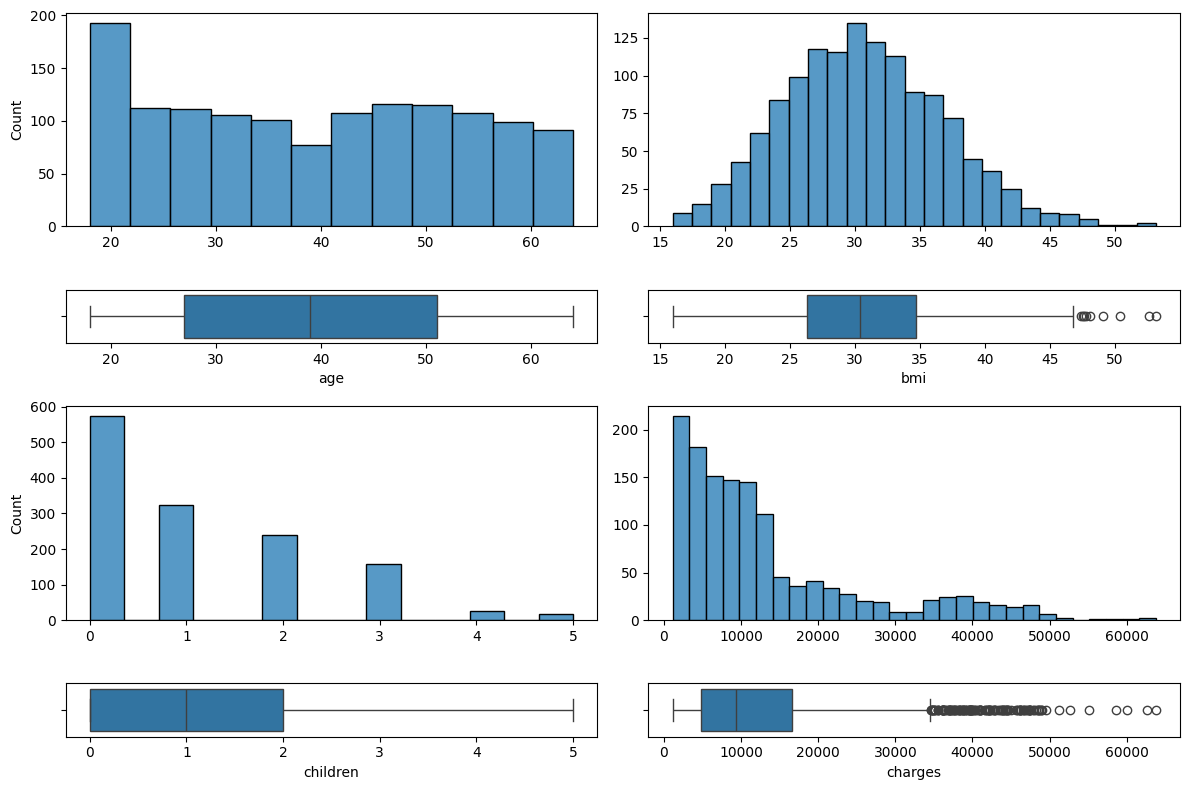

In [161]:
fig, axis = plt.subplots(4, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [4, 1, 4, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax=axis[0, 0], data=df, x='age').set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='bmi').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x='bmi')
sns.histplot(ax=axis[2, 0], data=df, x='children').set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x='children')
sns.histplot(ax=axis[2, 1], data=df, x='charges').set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x='charges')

plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - El histograma muestra una distribución bastante uniforme entre los 20 y 60 años.
> - El histograma de `bmi` tiene forma aproximadamente normal pero con ligera cola derecha: el grueso de los valores se concentra entre 25 y 35, con un pico alrededor de 30.
> - La mayoría de personas tienen 0 o 1 hijo, y la frecuencia cae claramente a medida que aumenta el número de hijos (muy pocos con 4 o 5).
> - La distribución de `charges` está fuertemente sesgada a la derecha: muchos individuos pagan primas/bills relativamente bajas, pero hay una larga cola de valores altos (hasta ~60.000).

#### Análisis numérico-numérico

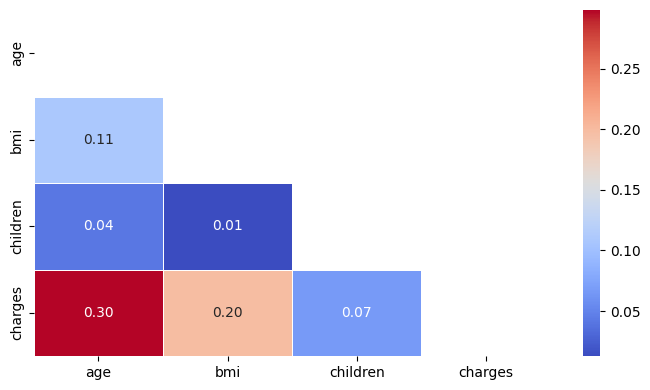

In [162]:
corr = df[['age', 'bmi', 'children', 'charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7,4))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='coolwarm')

plt.tight_layout()
plt.show()

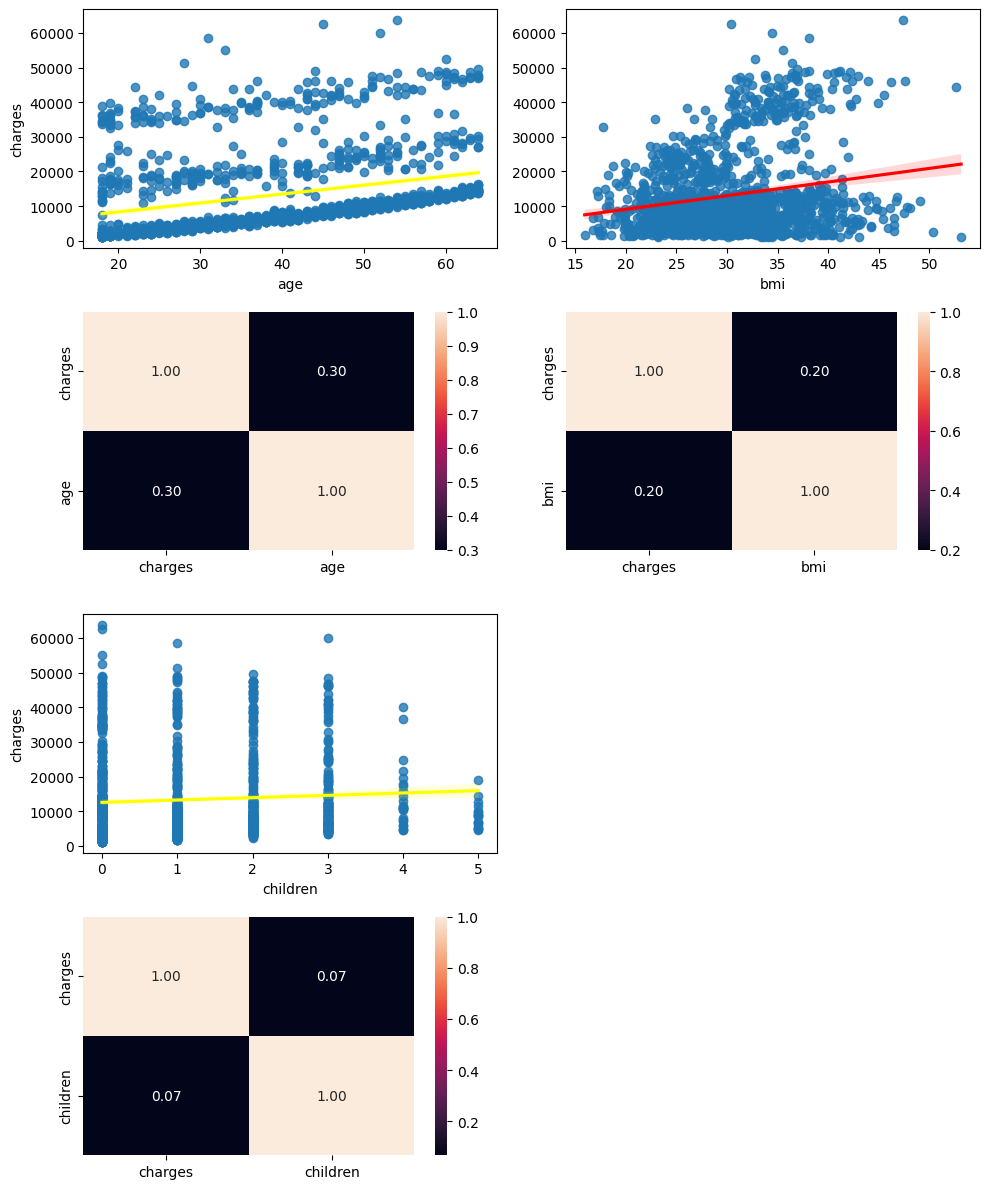

In [163]:
# We generate the correlations
corr_charges_age = df[['charges', 'age']].corr()
corr_charges_bmi = df[['charges', 'bmi']].corr()
corr_charges_children = df[['charges', 'children']].corr()

# Create a multiple scatter plot
fig, axis = plt.subplots(4, 2, figsize=(10, 12))

sns.regplot(ax=axis[0, 0], data=df, x='age', y='charges', line_kws={'color': 'yellow'})
sns.heatmap(ax=axis[1, 0], data=corr_charges_age, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 1], data=df, x='bmi', y='charges', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_charges_bmi, annot=True, fmt=".2f")

sns.regplot(ax=axis[2, 0], data=df, x='children', y='charges', line_kws={'color': 'yellow'})
sns.heatmap(ax=axis[3, 0], data=corr_charges_children, annot=True, fmt=".2f")

fig.delaxes(axis[2,1])
fig.delaxes(axis[3,1])

plt.tight_layout()
plt.show()

> ##### Observaciones
>
> - Existe una relación directa y positiva, aunque no muy fuerte, entre las variables `edad`y `charges`. El resto de variables presenta una correlación más débil.

#### Análisis categórico-categórico

##### Charges - (Sex, Smoker)

Primero analizamos el target frente a las características categóricas, una a una. Aquí no habrá combinaciones de varias predictoras y el target:

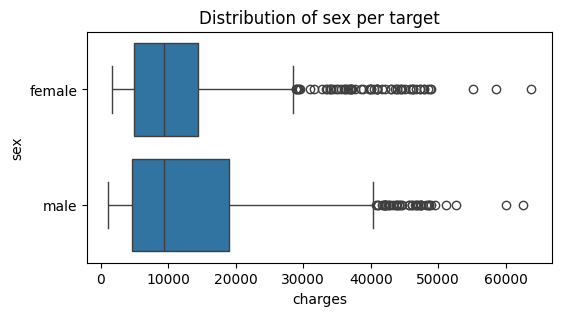

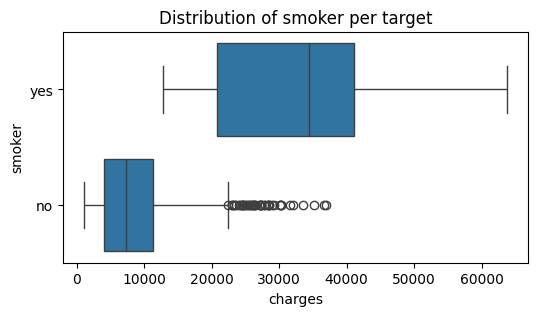

In [164]:
numerical_variables = ['sex', 'smoker']

for _ in numerical_variables:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='charges', y=_, data=df)
    plt.title(f'Distribution of {_} per target')
    plt.show()

> ##### Observaciones:
>
> De los gráficos anteriores podemos obtener las siguientes conclusiones:
> El sexo por sí solo no parece un fuerte determinante del nivel de `charges`.
> Los fumadores tienen una mediana de `charges` mucho más alta que los que no fuman. 
En general, ser fumador está fuertemente asociado con costes médicos más altos, por lo que la variable `smoker` es un predictor clave para explicar `charges`, mucho más relevante que `sex`.


##### Combinaciones del target con varias predictoras

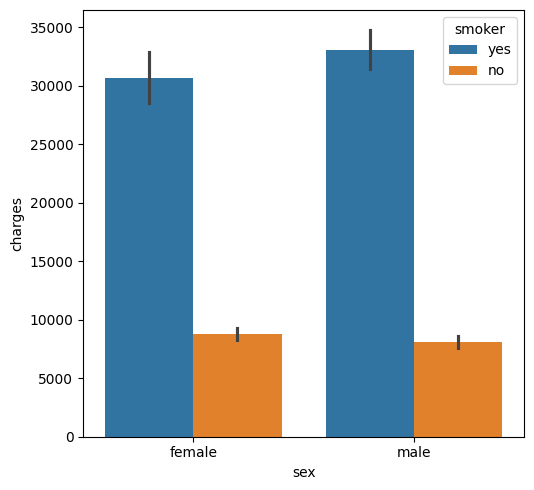

In [165]:
fig, axis = plt.subplots(figsize=(10, 5), ncols=2)

sns.barplot(ax=axis[0], data=df, x='sex', y='charges', hue='smoker')

fig.delaxes(axis[1])
plt.tight_layout()
plt.show()

> ##### Observaciones:
>
> - De este gráfico se observa claramente que, tanto en mujeres como en hombres, las personas fumadoras pagan una tasa más alta en comparación con quienes no fuman.

#### Análisis numérico-categórico (completo)

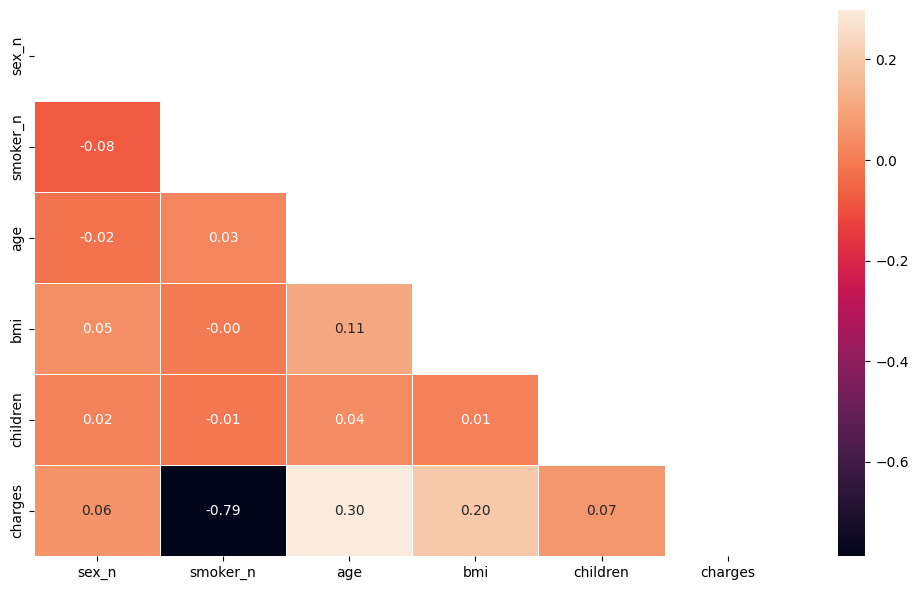

In [166]:
corr = df[['sex_n', 'smoker_n', 'age', 'bmi', 'children', 'charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

> ##### Observaciones:
>
> - `Smoker_n` tiene una correlación muy fuerte y negativa con `charges` (~−0.79), lo que nos vuelve a indicar que los fumadores pagan mucho más.
> - `Age` muestra correlación moderada positiva (~0.30): a mayor edad, mayores `charges` de media.
> - `Bmi` tiene correlación positiva (~0.20), por lo cual, tiende a asociarse con mayores gastos.
> - El número de hijos y el sexo aportan muy poca señal respecto a los costes.

#### Análisis de outliers

In [167]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801
sex_n,1337.0,0.504862,0.500163,0.0000,0.000,1.0000,1.00000,1.00000
smoker_n,1337.0,0.795064,0.403806,0.0000,1.000,1.0000,1.00000,1.00000


**Outliers: Visualización**

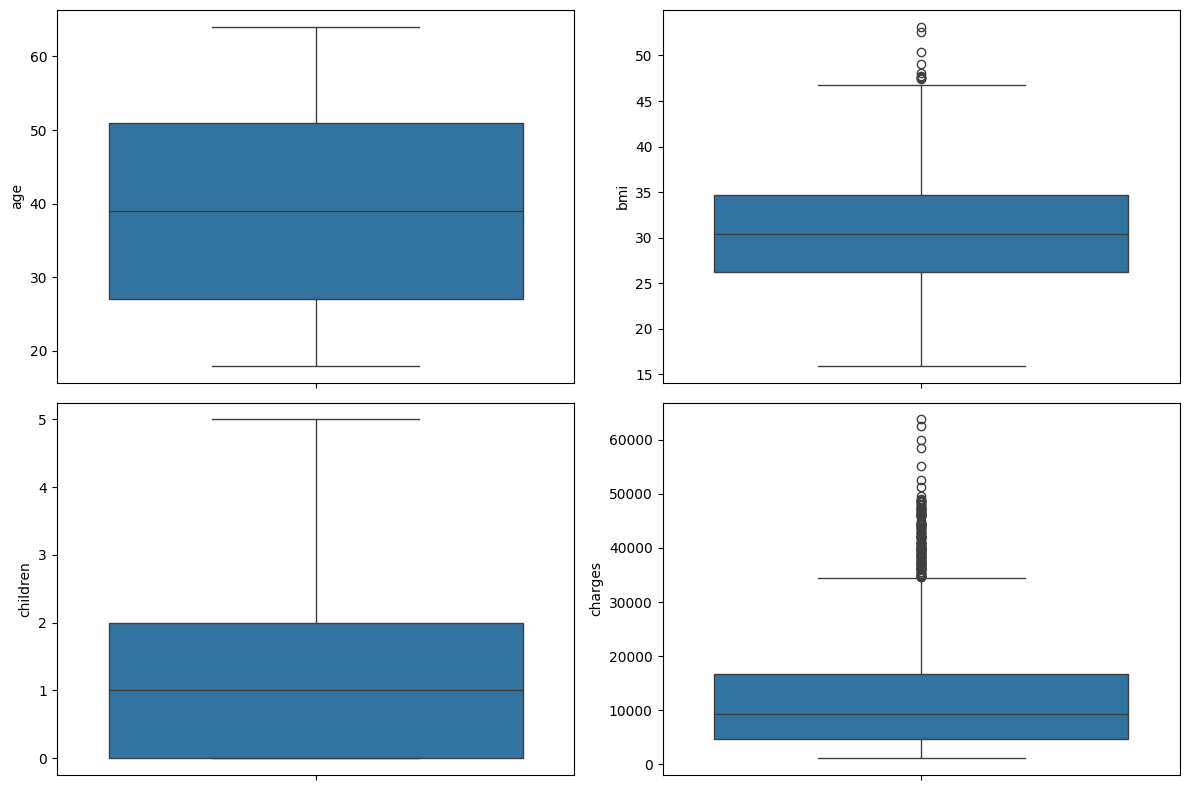

In [168]:
fig, axis = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(ax=axis[0, 0], data=df, y='age')
sns.boxplot(ax=axis[0, 1], data=df, y='bmi')
sns.boxplot(ax=axis[1, 0], data=df, y='children')
sns.boxplot(ax=axis[1, 1], data=df, y='charges')

plt.tight_layout()
plt.show()

> #### Observaciones
>
> Podemos determinar fácilmente que las variables afectadas por outliers son `charges` y `bmi`. Deberíamos establecer límites superior e inferior para determinar si un punto de datos debe considerarse o no un valor atípico.

In [169]:
charges_stats = df['charges'].describe()
charges_stats

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [170]:
# To calculate the interquartile range: IQR = Q3 (75%) - Q1 (25%)
q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)
iqr = q3 - q1

# Set the lower and upper limits
lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 34524.78, límite inferior: 0, rango intercuartílico: 11911.37'

> #### Observaciones
>
> Basándonos en estos resultados, deberíamos eliminar los registros con un `charge` mayor a 34525,00. Según los precios observados en el diagrama de caja, los valores extremos se encuentran por encima de 50000,00. 

In [171]:
# To see how many values represent that extreme value:
df[df['charges'] > 50000]

,age,sex,bmi,children,smoker,charges,sex_n,smoker_n
34,28,male,36.400,1,yes,51194.55914,1,0
543,54,female,47.410,0,yes,63770.42801,0,0
577,31,female,38.095,1,yes,58571.07448,0,0
819,33,female,35.530,0,yes,55135.40209,0,0
1146,60,male,32.800,0,yes,52590.82939,1,0
1230,52,male,34.485,3,yes,60021.39897,1,0
1300,45,male,30.360,0,yes,62592.87309,1,0


> #### Conclusiones
>
> Todos los que supera el `charge` de 50000 son fumadores y el `bmi`de algunos supera la media; por lo tanto, decidimos mantener los valores atípicos.

In [172]:
bmi_stats = df['bmi'].describe()
bmi_stats

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

In [173]:
q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
iqr = q3 - q1

lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 47.32, límite inferior: 13.67, rango intercuartílico: 8.41'

> #### Observaciones
>
> Basándonos en estos resultados, deberíamos eliminar los registros con un `bmi` mayor a 47,32. Según los resultados observados en el diagrama de caja, los valores extremos se encuentran por encima de 50,00.

In [174]:
df[df['bmi'] > 50]

,age,sex,bmi,children,smoker,charges,sex_n,smoker_n
847,23,male,50.38,1,no,2438.0552,1,1
1047,22,male,52.58,1,yes,44501.3982,1,0
1317,18,male,53.13,0,no,1163.4627,1,1


> #### Conclusiones
>
> Casi todos los registros con valores altos de `bmi` van acompañados de `charges` elevados. En el último caso, aunque el `bmi` también es muy alto, el cargo es más bajo porque se trata de una persona de 18 años, muy joven y no fumadora. Dado que estos valores son clínicamente plausibles con el comportamiento de charges, decidimos mantener estos valores atípicos.

#### Análisis de valores faltantes

In [175]:
df.shape[1]

8

In [176]:
df.isnull().sum() / df.shape[0]

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
charges     0.0
sex_n       0.0
smoker_n    0.0
dtype: float64

> #### Observaciones
>
> En este caso no contamos con valores faltantes.

#### Split (dos métodos o enfoques)

> Antes de realizar el split, vamos a eliminar las columnas que fueron convertidas a números mediante el método `factorize` para la elaboración de los gráficos.

In [177]:
df.drop(['sex_n', 'smoker_n'], axis=1, inplace=True)
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [178]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [179]:
X_train

,age,sex,bmi,children,smoker
1154,48,female,27.930,4,no
1101,53,male,28.600,3,no
662,32,female,31.540,1,no
147,51,female,37.730,1,no
534,64,male,40.480,0,no
...,...,...,...,...,...
1199,31,female,25.800,2,no
838,35,female,23.465,2,no
1145,52,male,32.775,3,no
275,47,female,26.600,2,no


In [180]:
X_train.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker'], dtype='object')

In [181]:
y_test.shape

(268,)

#### Encoding - One Hot Encoding

> Para las variables `sex`y `smoker` utilizamos el metodo One Hot encoding porque tenemos pocas categorías (menos de 10) y no tienen order real.

In [182]:
# To generate a list with the names of the categorical columns
categorical_variables = ['sex', 'smoker']

# We create the encoder instance
onehot_encoder = OneHotEncoder(sparse_output=False)

# We train the encoder with the training data (we adjust it).
onehot_encoder.fit(X_train[categorical_variables])

# We apply the encoder to the training set: X_train
X_train_cat_ohe = onehot_encoder.transform(X_train[categorical_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(categorical_variables))

# We apply the encoder to the test set: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[categorical_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(categorical_variables))

X_train_cat_ohe.head()

,sex_female,sex_male,smoker_no,smoker_yes
1154,1.0,0.0,1.0,0.0
1101,0.0,1.0,1.0,0.0
662,1.0,0.0,1.0,0.0
147,1.0,0.0,1.0,0.0
534,0.0,1.0,1.0,0.0


#### Scaling - Escalado de valores

In [183]:
numerical_variables = ['age', 'children', 'bmi']
X_train_numerical = X_train[numerical_variables]
X_test_numerical = X_test[numerical_variables]

In [184]:
X_train_full = pd.concat([X_train_numerical, X_train_cat_ohe], axis=1)
X_test_full = pd.concat([X_test_numerical, X_test_cat_ohe], axis=1)

In [198]:
X_train_full

,age,children,bmi,sex_female,sex_male,smoker_no,smoker_yes
1154,48,4,27.930,1.0,0.0,1.0,0.0
1101,53,3,28.600,0.0,1.0,1.0,0.0
662,32,1,31.540,1.0,0.0,1.0,0.0
147,51,1,37.730,1.0,0.0,1.0,0.0
534,64,0,40.480,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...
1199,31,2,25.800,1.0,0.0,1.0,0.0
838,35,2,23.465,1.0,0.0,1.0,0.0
1145,52,3,32.775,0.0,1.0,1.0,0.0
275,47,2,26.600,1.0,0.0,1.0,0.0


Utilizamos el escalado estándar (StandardScaler):

In [185]:
final_numerical_variables = ['age', 'sex_female', 'sex_male', 'children', 'smoker_no', 'smoker_yes', 'bmi']
norm_scaler = StandardScaler()

X_train_scaled_number = norm_scaler.fit_transform(X_train_full[final_numerical_variables])
X_test_scaled_number = norm_scaler.transform(X_test_full[final_numerical_variables])

# We convert it to DataFrame
X_train_cat_le_scaled = pd.DataFrame(X_train_scaled_number, 
                                     index=X_train_full.index,
                                     columns=final_numerical_variables)

X_test_cat_le_scaled = pd.DataFrame(X_test_scaled_number,
                                     index=X_test_full.index,
                                     columns=final_numerical_variables)

X_train_cat_le_scaled.head()

,age,sex_female,sex_male,children,smoker_no,smoker_yes,bmi
1154,0.599173,1.016031,-1.016031,2.471207,0.494439,-0.494439,-0.468641
1101,0.954344,-0.984222,0.984222,1.626127,0.494439,-0.494439,-0.357833
662,-0.537375,1.016031,-1.016031,-0.064033,0.494439,-0.494439,0.128401
147,0.812276,1.016031,-1.016031,-0.064033,0.494439,-0.494439,1.152140
534,1.735721,-0.984222,0.984222,-0.909113,0.494439,-0.494439,1.606951


## Paso 3: El modelo de regresión lineal

#### Inicialización y entrenamiento del modelo

In [186]:
X_train_cat_le_scaled

,age,sex_female,sex_male,children,smoker_no,smoker_yes,bmi
1154,0.599173,1.016031,-1.016031,2.471207,0.494439,-0.494439,-0.468641
1101,0.954344,-0.984222,0.984222,1.626127,0.494439,-0.494439,-0.357833
662,-0.537375,1.016031,-1.016031,-0.064033,0.494439,-0.494439,0.128401
147,0.812276,1.016031,-1.016031,-0.064033,0.494439,-0.494439,1.152140
534,1.735721,-0.984222,0.984222,-0.909113,0.494439,-0.494439,1.606951
...,...,...,...,...,...,...,...
1199,-0.608409,1.016031,-1.016031,0.781047,0.494439,-0.494439,-0.820913
838,-0.324272,1.016031,-1.016031,0.781047,0.494439,-0.494439,-1.207089
1145,0.883310,-0.984222,0.984222,1.626127,0.494439,-0.494439,0.332653
275,0.528139,1.016031,-1.016031,0.781047,0.494439,-0.494439,-0.688605


In [187]:
y_train

1154    11015.17470
1101    11253.42100
662      5148.55260
147      9877.60770
534     13831.11520
           ...     
1199     4934.70500
838      6402.29135
1145    11289.10925
275      9715.84100
1323    43896.37630
Name: charges, Length: 1069, dtype: float64

In [188]:
X_test_cat_le_scaled

,age,sex_female,sex_male,children,smoker_no,smoker_yes,bmi
381,1.096412,-0.984222,0.984222,-0.909113,-2.022493,2.022493,-0.013003
38,-0.324272,-0.984222,0.984222,-0.064033,-2.022493,2.022493,0.976831
197,0.386070,1.016031,-1.016031,0.781047,0.494439,-0.494439,-0.357833
14,-0.892546,-0.984222,0.984222,-0.909113,-2.022493,2.022493,1.879837
94,1.735721,1.016031,-1.016031,0.781047,-2.022493,2.022493,0.088709
...,...,...,...,...,...,...,...
978,0.386070,1.016031,-1.016031,1.626127,0.494439,-0.494439,1.526739
1109,0.386070,-0.984222,0.984222,1.626127,0.494439,-0.494439,-1.722266
8,-0.182204,-0.984222,0.984222,0.781047,0.494439,-0.494439,-0.154408
809,-1.034615,-0.984222,0.984222,-0.064033,0.494439,-0.494439,-0.814298


In [189]:
y_test

381     42303.69215
38      39774.27630
197      8516.82900
14      39611.75770
94      47291.05500
           ...     
978      9704.66805
1109     8605.36150
8        6406.41070
809      3309.79260
817      3597.59600
Name: charges, Length: 268, dtype: float64

In [190]:
model = LinearRegression()
model.fit(X_train_cat_le_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [191]:
# Intercept (a)
model.intercept_

np.float64(13251.365239456502)

In [192]:
# Coefficients (b)
model.coef_

array([ 3621.38730075,    50.01673978,   -50.01673978,   556.22278764,
       -4829.02222159,  4829.02222159,  1828.87870357])

#### Predicción del modelo

In [193]:
y_pred = model.predict(X_test_cat_le_scaled)
y_pred

array([36127.31606431, 33262.80598649,  9755.79713906, 32386.30295003,
       39768.71578633,  4365.52715848, 27894.186697  , 38053.25387149,
       35185.92017229, 31315.11312108,   805.44779089,  2974.87445881,
       11962.81050286, 11352.63277821, 14565.27719902, 11745.82766747,
       12794.02674672, 11332.66213806,  8892.90528115, 28563.86192604,
       35647.753552  ,  8289.78558216,  3173.75854673, 11077.05247871,
       15862.16811492,  2090.29029678, 26966.77571134, 11379.17547152,
        4795.46279072, 26214.27329626,  8965.80333726, 12978.10650244,
       11304.50954161,  7417.21727509, 13524.71546237,  2218.12809758,
        9753.54236798, 34027.57986977, 16242.46864127,  3428.01063542,
        4798.06016575, 34840.52153519, 11972.93121887, 34058.49661426,
       25278.27735221, 32355.91025468, 24636.46983208,  5883.98015884,
        9335.51362676, 26099.96605957, 10811.28132247,  1476.32439942,
       13520.96160164,  5382.21328376,  3730.72361961, 16491.44125254,
      

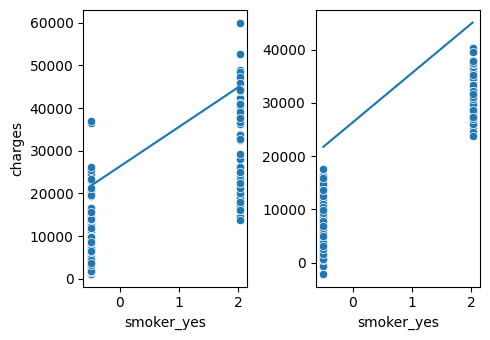

In [194]:
X_train_cat_le_scaled['charges'] = y_train.values
X_test_cat_le_scaled['charges'] = y_test.values

fig, axis = plt.subplots(1, 2, figsize=(5, 3.5))
total_data = pd.concat([X_train_cat_le_scaled, X_test_cat_le_scaled])

# We use the parameters adjusted in the training to draw the regression line on the graphs
regression_equation = lambda x: 26354.43069701219 + 9277.78307971 * x

sns.scatterplot(ax=axis[0], data=X_test_cat_le_scaled, x='smoker_yes', y='charges')
sns.lineplot(ax=axis[0], x=X_test_cat_le_scaled['smoker_yes'], y=regression_equation(X_test_cat_le_scaled['smoker_yes']))
sns.scatterplot(ax=axis[1], x=X_test_cat_le_scaled['smoker_yes'], y=y_pred)
sns.lineplot(ax=axis[1], x=X_test_cat_le_scaled['smoker_yes'], y=regression_equation(X_test_cat_le_scaled['smoker_yes'])).set(ylabel = None)

plt.tight_layout()

plt.show()

> #### Observaciones
>
>  La figura de la izquierda representa los valores reales, mientras que los de la derecha, los predichos. Vemos que algunos valores predichos coinciden con los reales, y los que no, tienen una diferencia notable.

In [195]:
# To calculate the effectiveness of the model we will use the mean squared error (MSE) and the coefficient of determination R2
# Mean squared error
mean_squared_error(y_test, y_pred)

40728114.116710916

In [196]:
# Coefficient of determination
r2_score(y_test, y_pred)

0.717882233237652

> #### Observaciones
>
>  Observamos que en el conjunto de test, el modelo obtuvo las siguientes métricas:
> - MSE = 40,728,114.12
> - R2 = 0.718
> Podemos concluir que el modelo capta bien la tendencia general (R2 es sólido), pero comete errores importantes en casos concretos, lo que se ve reflejado en el MSE elevado.
> Para mejorar el model se podría probar:
> - eliminar o tratar outliers
> - probar regularización